In [1]:
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from ultralytics import YOLO,solutions
import cv2

In [ ]:
# Load YOLO model
model = YOLO('models/yolo11n.pt')

In [3]:
# Initialize webcam (0 or 1 for local cameras)
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()
else : print(cap)

In [4]:
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))

# Define points for a line or region of interest in the video frame
region_points = [(0, 400), (1080, 400), (1080, 360), (0, 360)]  # Line coordinates

# Initialize object counter
counter = solutions.ObjectCounter(
    show=False,
    region=region_points,
    model='models/best.pt'
)

counts = []

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    # Track and count objects
    track = model.track(frame, persist=True, show=False, conf=0.59)
    count = counter.count(frame)
    counts.append(count)
    
    counter.store_classwise_counts
    print(counter.classwise_counts)
    
    # Display video frame
    cv2.imshow("Mango Tracking", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


In [75]:
print(counter.classwise_counts)

In [83]:
# Save the counts to a CSV file
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Check if total.csv exists
if not os.path.exists('total.csv'):
    # Create a new DataFrame and save it as total.csv
    df = pd.DataFrame(columns=['Class', 'IN', 'OUT'])
    df.to_csv('total.csv', index=False)
    print("total.csv created.")
else:
    print("total.csv already exists.")

In [76]:
for grade, directions in counter.classwise_counts.items():
    print(f"Grade: {grade}, IN: {directions['IN']}, OUT: {directions['OUT']}")

In [84]:
# Extract classwise counts and convert to a DataFrame
data = []
for grade, directions in counter.classwise_counts.items():
    data.append({'Class': grade, 'IN': directions['IN'], 'OUT': directions['OUT']})

classwise_counts_df = pd.DataFrame(data)

# Append the new data to the existing total.csv
classwise_counts_df.to_csv('total.csv', mode='a', header=False, index=False)
print("Data appended to total.csv.")

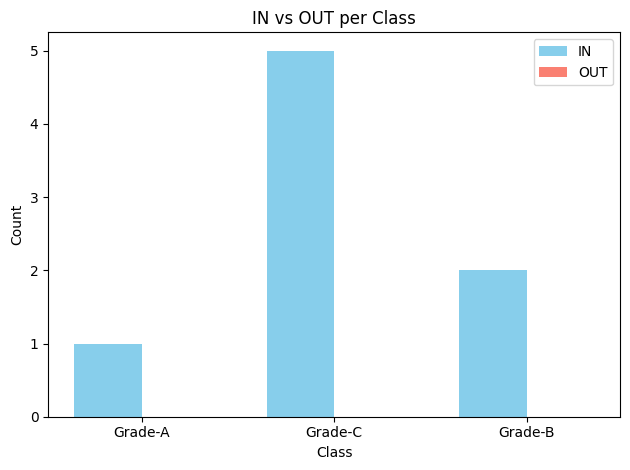

In [ ]:
total_df = pd.read_csv('total.csv')

x = np.arange(len(total_df['Class']))
width = 0.35

# Plot
plt.bar(x - width/2, total_df['IN'], width, label='IN', color='skyblue')
plt.bar(x + width/2, total_df['OUT'], width, label='OUT', color='salmon')

# Labels
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('IN vs OUT per Class')
plt.xticks(x, total_df['Class'])
plt.legend()

plt.tight_layout()
plt.show()

In [64]:
total_df = pd.read_csv('total.csv')

In [65]:
print(total_df)

In [17]:
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))

# Define points for a line or region of interest in the video frame
region_points = [(0, 400), (1080, 400), (1080, 360), (0, 360)]  # Line coordinates

# Initialize object counter
counter = solutions.ObjectCounter(
    show=False,
    region=region_points,
    model='models/best.pt'
)

counts = []

In [33]:
import threading
import time

frame = None
stop_thread = False
lock = threading.Lock()

def mango_tracking():
    global frame, stop_thread
    while not stop_thread:
        ret, local_frame = cap.read()
        if not ret:
            print("Error: Could not read frame.")
            break

        # Track and count objects
        track = model.track(local_frame, persist=True, show=False, conf=0.59)
        counts = counter.count(local_frame)
        
        counter.store_classwise_counts
        print(counter.classwise_counts)
        
        # Store the frame safely using a lock
        with lock:
            frame = local_frame.copy()  # Ensure a deep copy to prevent corruption

        time.sleep(0.01)

In [ ]:
# Run the function in a separate thread
tracking_thread = threading.Thread(target=mango_tracking, daemon=True)
tracking_thread.start()

while True:
    with lock:
        if frame is not None:
            cv2.imshow("Mango Tracking", frame)
            time.sleep(0.01)

    key = cv2.waitKey(1) & 0xFF
    if key == ord("q") or key == ord("0"):
        stop_thread = True
        break
    

# Cleanup
tracking_thread.join()
cap.release()
cv2.destroyAllWindows()

In [35]:
stop_thread = True  # Set the flag to stop the loop
tracking_thread.join()  # Wait for the thread to finish
cv2.destroyAllWindows()


In [21]:
cap.release()